In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# 1. Загрузка данных

FILE_PATH = "Данные_для_курсовои_Классическое_МО.xlsx"
TARGET = "IC50, mM"
ID_COL = "Unnamed: 0"
RANDOM_STATE = 42

df = pd.read_excel(FILE_PATH)

if ID_COL in df.columns:
    df = df.drop(columns=[ID_COL])

X = df.drop(columns=["IC50, mM", "CC50, mM", "SI"])
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"{TARGET} median = {y.median():.6f}")


X shape: (1001, 210)
y shape: (1001,)
IC50, mM median = 46.585183


In [6]:
# 2. Train / Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 210)
Test shape: (201, 210)


In [7]:
# 3. Вспомогательные функции

def regression_metrics(y_true, y_pred, prefix=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        f"{prefix}MAE": mean_absolute_error(y_true, y_pred),
        f"{prefix}RMSE": rmse,
        f"{prefix}R2": r2_score(y_true, y_pred)
    }

def build_ridge():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ])
    model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    return model

def build_rf():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    return model

def build_et():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    return model

def build_gbr():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ])
    model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    return model

In [8]:
# 4. Базовые модели

models = {
    "Ridge": build_ridge(),
    "RandomForest": build_rf(),
    "ExtraTrees": build_et(),
    "GradientBoosting": build_gbr()
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error"
        },
        n_jobs=-1,
        return_train_score=False
    )

    baseline_results.append({
        "Model": name,
        "CV_MAE_mean": -scores["test_mae"].mean(),
        "CV_MAE_std": scores["test_mae"].std(),
        "CV_RMSE_mean": -scores["test_rmse"].mean(),
        "CV_R2_mean": scores["test_r2"].mean()
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("CV_MAE_mean")
print("\nБазовые модели (5-fold CV):")
display(baseline_df)


Базовые модели (5-fold CV):


,Model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean
3,GradientBoosting,1.577035e+02,7.435222e+00,3.000885e+02,2.201817e-01
1,RandomForest,1.594793e+02,1.083937e+01,2.994751e+02,2.229474e-01
2,ExtraTrees,1.628550e+02,1.074261e+01,3.029966e+02,2.031675e-01
0,Ridge,2.761320e+10,5.522619e+10,3.492825e+11,-5.477062e+18


In [9]:
# 5. Подбор гиперпараметров

search_spaces = {
    "Ridge": {
        "regressor__model__alpha": np.logspace(-3, 3, 100)
    },
    "RandomForest": {
        "regressor__model__n_estimators": [200, 300, 500, 700],
        "regressor__model__max_depth": [None, 5, 10, 15, 20, 30],
        "regressor__model__min_samples_split": [2, 5, 10],
        "regressor__model__min_samples_leaf": [1, 2, 4],
        "regressor__model__max_features": ["sqrt", "log2", 0.5, 0.8]
    },
    "ExtraTrees": {
        "regressor__model__n_estimators": [200, 300, 500, 700],
        "regressor__model__max_depth": [None, 5, 10, 15, 20, 30],
        "regressor__model__min_samples_split": [2, 5, 10],
        "regressor__model__min_samples_leaf": [1, 2, 4],
        "regressor__model__max_features": ["sqrt", "log2", 0.5, 0.8]
    },
    "GradientBoosting": {
        "regressor__model__n_estimators": [100, 200, 300, 500],
        "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "regressor__model__max_depth": [2, 3, 4, 5],
        "regressor__model__subsample": [0.7, 0.8, 1.0],
        "regressor__model__min_samples_split": [2, 5, 10]
    }
}

best_models = {}
tuning_results = []

for name, model in models.items():
    print(f"\nПодбор гиперпараметров для {name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=search_spaces[name],
        n_iter=20,
        scoring="neg_mean_absolute_error",
        cv=cv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best_CV_MAE": -search.best_score_,
        "Best_Params": search.best_params_
    })

tuning_df = pd.DataFrame(tuning_results).sort_values("Best_CV_MAE")
print("\nРезультаты подбора гиперпараметров:")
display(tuning_df)


Подбор гиперпараметров для Ridge...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для RandomForest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для ExtraTrees...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Подбор гиперпараметров для GradientBoosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Результаты подбора гиперпараметров:


,Model,Best_CV_MAE,Best_Params
3,GradientBoosting,153.761720,"{'regressor__model__subsample': 0.8, 'regresso..."
2,ExtraTrees,153.900537,"{'regressor__model__n_estimators': 200, 'regre..."
1,RandomForest,157.221242,"{'regressor__model__n_estimators': 200, 'regre..."
0,Ridge,169.638220,{'regressor__model__alpha': 26.560877829466893}


In [10]:
# 6. Финальная оценка на test

test_results = []

for name, model in best_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    metrics = regression_metrics(y_test, preds)
    metrics["Model"] = name
    test_results.append(metrics)

test_df = pd.DataFrame(test_results).sort_values("MAE")
print("\nРезультаты на тестовой выборке:")
display(test_df)


Результаты на тестовой выборке:


,MAE,RMSE,R2,Model
0,218.667446,471.677680,0.333012,Ridge
2,222.377177,481.836935,0.303971,ExtraTrees
1,225.571844,500.680265,0.248467,RandomForest
3,228.364387,468.307778,0.342509,GradientBoosting


In [11]:
# 7. Выбор лучшей модели

best_model_name = test_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print(f"\nЛучшая модель по MAE на test: {best_model_name}")

best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)


Лучшая модель по MAE на test: Ridge


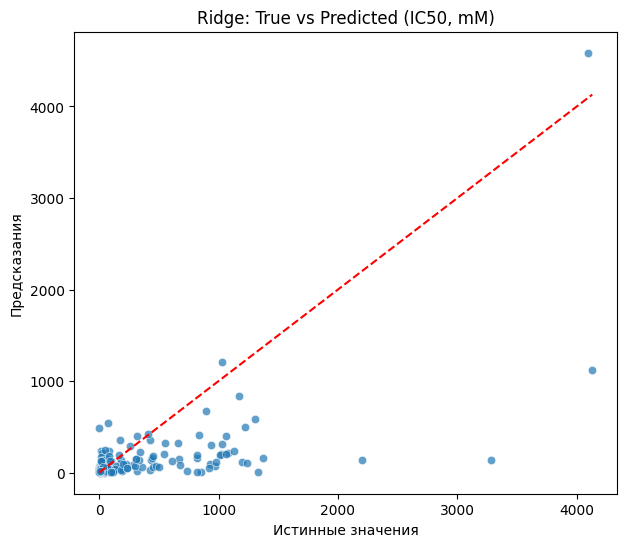

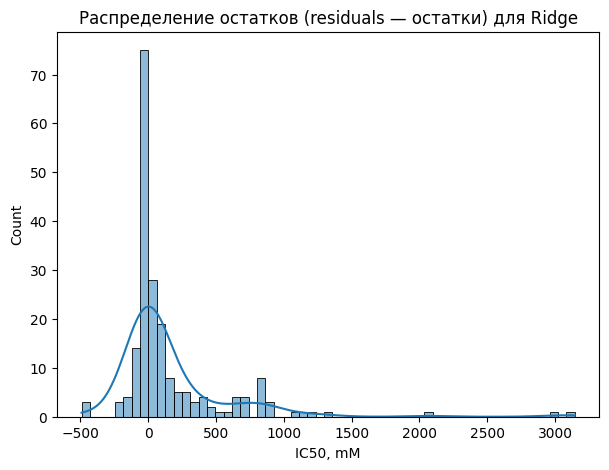

In [12]:
# 8. Графики качества

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Истинные значения")
plt.ylabel("Предсказания")
plt.title(f"{best_model_name}: True vs Predicted ({TARGET})")
plt.show()

residuals = y_test - best_preds

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True)
plt.title(f"Распределение остатков (residuals — остатки) для {best_model_name}")
plt.show()


Топ-20 наиболее важных признаков:


,feature,importance
44,Kappa3,0.474877
139,fr_NH2,0.420019
21,BCUT2D_LOGPHI,0.413652
124,fr_Al_OH_noTert,0.366658
77,SlogP_VSA6,0.318475
36,Chi3n,0.303435
37,Chi3v,0.302684
136,fr_Imine,0.289894
117,NumSaturatedHeterocycles,0.286320
81,EState_VSA1,0.279107


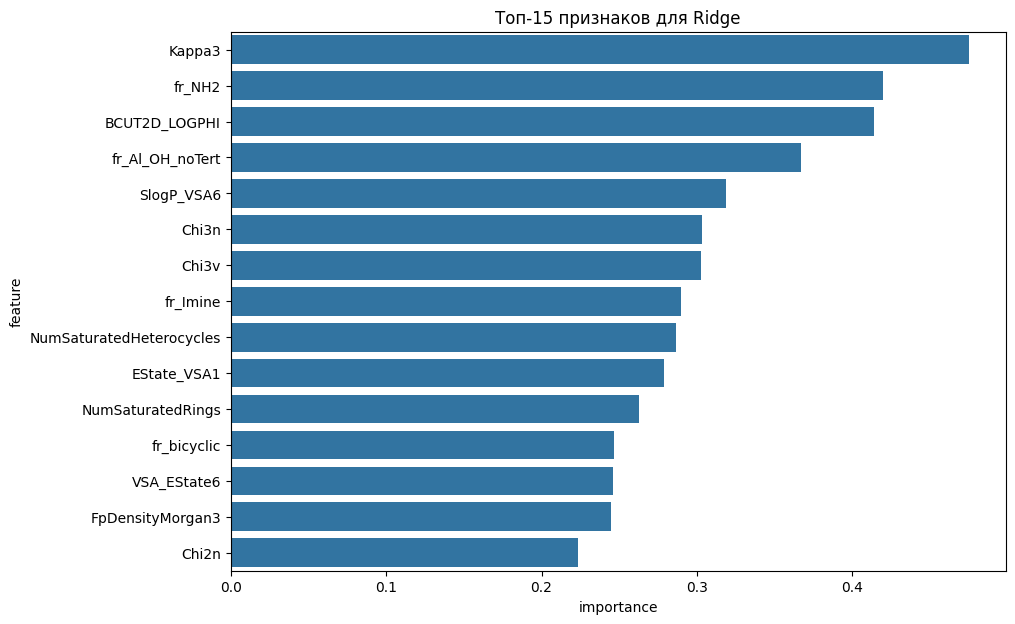

In [13]:
# 9. Важность признаков

# Для древовидных моделей можно извлечь feature_importances_
# Для Ridge используем абсолютные коэффициенты
best_regressor = best_model.regressor_

# Получим список признаков после VarianceThreshold
X_train_imputed = pd.DataFrame(
    best_regressor.named_steps["imputer"].fit_transform(X_train),
    columns=X_train.columns
)

variance_selector = best_regressor.named_steps["variance"]
selected_features = X_train.columns[variance_selector.get_support()]

final_model = best_regressor.named_steps["model"]

if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_
    fi = pd.DataFrame({
        "feature": selected_features,
        "importance": importances
    }).sort_values("importance", ascending=False)

elif hasattr(final_model, "coef_"):
    importances = np.abs(final_model.coef_)
    fi = pd.DataFrame({
        "feature": selected_features,
        "importance": importances
    }).sort_values("importance", ascending=False)

else:
    fi = None

if fi is not None:
    print("\nТоп-20 наиболее важных признаков:")
    display(fi.head(20))

    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi.head(15), x="importance", y="feature")
    plt.title(f"Топ-15 признаков для {best_model_name}")
    plt.show()

ИТОГОВЫЕ ВЫВОДЫ ПО IC50
1. Для задачи регрессии IC50 были сравнены 4 модели: Ridge, RandomForest, ExtraTrees, GradientBoosting.
2. Использовано log1p-преобразование целевой переменной из-за сильной асимметрии распределения.
3. Качество оценивалось по MAE, RMSE и R2.
4. После подбора гиперпараметров лучшей признаётся модель: {best_model_name}.
5. Основной критерий выбора — минимальный MAE на test и устойчивое качество на 5-fold CV.
6. Для химических дескрипторов ансамбли деревьев часто превосходят линейные модели за счёт моделирования нелинейных зависимостей.
7. Полученные feature importance помогают интерпретировать вклад молекулярных дескрипторов в активность соединений.
